#### *Importing necessary libraries*

In [1281]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

#### *Importing dataset*

In [1282]:
df=pd.read_csv('insurance.csv')

#### *EDA*

In [1283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [1284]:
df.duplicated().sum()

np.int64(1)

In [1285]:
df=df.drop_duplicates()

In [1286]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [1287]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

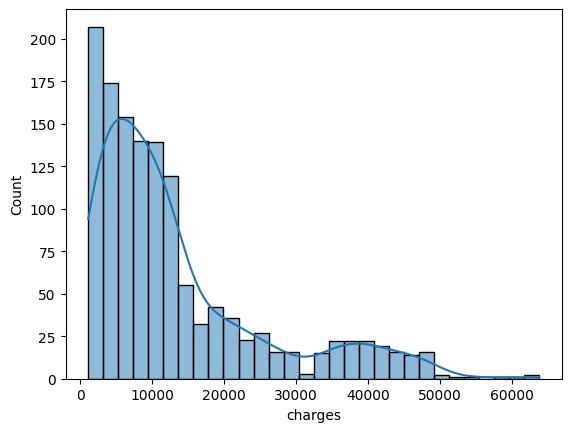

In [1288]:
# Visualizing the distribution of charges (dependent variable)
# Observation: distribution is right-skewed (not normally distributed)
sns.histplot(df['charges'],bins=30,kde=True)
plt.show()

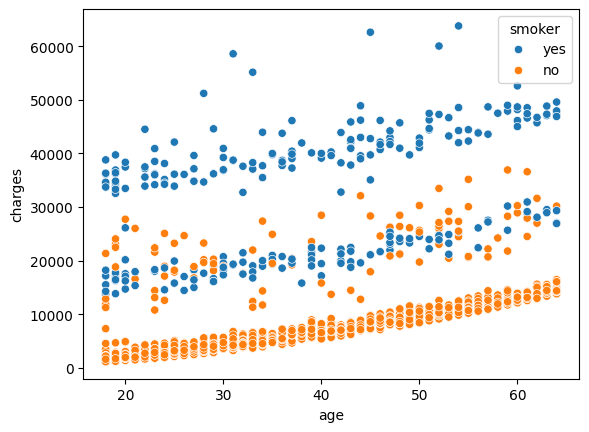

In [1289]:
# Scatter plot of age vs charges colored by smoker status
# to understand the non-normal distribution pattern in charges
sns.scatterplot(x=df['age'], y=df['charges'], hue=df['smoker'])
plt.show()

In [1290]:
# Investigating high charges. checking if they are associated with
# known risk factors (older age, smoker, high bmi)
# Conclusion: high charges appear justified by risk factors, not outliers
# Therefore, keeping these data points to preserve valuable training information
df[df['charges'] >30000][['age', 'bmi', 'smoker', 'charges']]

,age,bmi,smoker,charges
14,27,42.130,yes,39611.75770
19,30,35.300,yes,36837.46700
23,34,31.920,yes,37701.87680
29,31,36.300,yes,38711.00000
30,22,35.600,yes,35585.57600
...,...,...,...,...
1301,62,30.875,yes,46718.16325
1303,43,27.800,yes,37829.72420
1308,25,30.200,yes,33900.65300
1313,19,34.700,yes,36397.57600


#### *separating data into X (features) and y (target)*

In [1291]:
X=df.drop('charges', axis=1)
y=df[['charges']]

In [1292]:
# Identifying categorical and numerical columns
# categorical_cols → for OneHotEncoding | numerical_cols → passthrough
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#### *Splitting the data into training (80%) and test (20%) sets*

In [1293]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

#### *Building sklearn Pipeline — Encoding, Scaling and Model Training*

In [1294]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Scale y_train
sy = StandardScaler()
y_train_scaled = sy.fit_transform(y_train)

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='first',sparse_output=False),
     categorical_cols)], remainder='passthrough')

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler',       StandardScaler()),
    ('model',        SVR(kernel='rbf'))
])

# Train
pipeline.fit(X_train, y_train_scaled.ravel())

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### *Prediction on all features*

In [1295]:
y_pred=pd.DataFrame(sy.inverse_transform(pipeline.predict(X_test).reshape(-1,1)))

#### *Evaluation of Model Predictions Using All Features*

In [1296]:
r2i=(r2_score(y_test,y_pred))
print('R2 Sc : ',round(r2i,4))
MAE=(mean_absolute_error(y_test,y_pred))
print('MAE   : ',round(MAE,2))
print('MAPE  : ',round(mean_absolute_percentage_error(y_test,y_pred),4))
print('RMSE  : ',round(root_mean_squared_error(y_test,y_pred),2))
print('MAPEM : ',round(MAE/np.mean(y_test),4))

R2 Sc :  0.8403
MAE   :  2881.52
MAPE  :  0.247
RMSE  :  5182.76
MAPEM :  0.205


#### *Feature Importance Evaluation Using Permutation Importance for Feature Selection*

In [1297]:
from sklearn.inspection import permutation_importance
y_test_scaled = sy.transform(y_test)
result = permutation_importance(
pipeline,
X_test,
y_test_scaled,
n_repeats=30,
random_state=42
)
importance = result.importances_mean


#### *Feature importance by feature name*

In [1298]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
4,smoker,1.226303
2,bmi,0.217089
0,age,0.179217
3,children,0.010607
5,region,0.005846
1,sex,-0.000716


 #### *Iterative Feature Selection — Threshold Search with Early Stopping and Model Retraining*

In [1299]:
# r2i as baseline (already calculated with same pipeline)
best_r2        = r2i
best_threshold = None
best_features  = X.columns.tolist()
best_pipeline  = pipeline  # Original pipeline as default

# Early stopping patience
patience   = 6
bad_rounds = 0

# Sort thresholds LOW to HIGH gradually remove more features
thresholds = np.sort(importance_df['Importance'].unique())
print("Initial R2 with all features :", round(best_r2, 4))
print("="*60)

for threshold in thresholds:

    # Keep features ABOVE current threshold
    selected_features = importance_df[
        importance_df["Importance"] > threshold
    ]["Feature"].tolist()

    # Skip if no features left
    if len(selected_features) == 0:
        print(f"Threshold {threshold:.4f} — no features left, skipping")
        continue

    # Skip if same number of features (nothing was dropped yet)
    if len(selected_features) == len(best_features):
        continue

    X_train_sel = X_train[selected_features]
    X_test_sel  = X_test[selected_features]

    # Update categorical cols for selected features only
    categorical_cols_sel = [c for c in categorical_cols if c in selected_features]

    # Rebuild pipeline — SAME as original (StandardScaler)
    preprocessor_sel = ColumnTransformer(transformers=[
        ('encoder', OneHotEncoder(drop='first',sparse_output=False), categorical_cols_sel)
    ], remainder='passthrough')

    pipeline_sel = Pipeline(steps=[
        ('preprocessor', preprocessor_sel),
        ('scaler',        StandardScaler()),
        ('model',         SVR(kernel='rbf'))
    ])

    # Train
    pipeline_sel.fit(X_train_sel, y_train_scaled.ravel())
    

    # Predict and inverse transform
    y_pred_sel = sy.inverse_transform(
        pipeline_sel.predict(X_test_sel).reshape(-1, 1)
    )
    
    r2 = r2_score(y_test, y_pred_sel)

    improved = r2 > best_r2
    status   = "✅ Improved" if improved else "❌ No improvement"

    print(f"Threshold: {threshold:.4f} | Features: {len(selected_features):3d} | R2: {r2:.4f} | {status}")

    if improved:
        best_r2        = r2
        best_threshold = threshold
        best_features  = selected_features
        best_pipeline  = pipeline_sel  # ✅ save best pipeline
        bad_rounds     = 0
    else:
        bad_rounds += 1

    # Early stopping
    if bad_rounds >= patience:
        print(f"\n⛔ Early stopping triggered — no improvement for {patience} rounds")
        break

print("\n" + "="*60)
print("Best Threshold during search :",round(best_threshold, 6) if best_threshold is not None else "No Improvement")
print("Best R2 during search        :", round(best_r2, 4))
print("Selected Features Count      :", len(best_features))
print("Selected Features            :", best_features)
print("="*60)

# Use best_pipeline directly — no retraining needed
y_pred_final = sy.inverse_transform(
    best_pipeline.predict(X_test[best_features]).reshape(-1, 1)
)

final_r2 = r2_score(y_test, y_pred_final)

print("\n" + "="*60)
print("Final R2 with best features  :", round(final_r2, 4))
print("Baseline R2 with all features:", round(r2i, 4))
print("R2 Improvement               :", round(final_r2 - r2i, 4))
print("="*60)

Initial R2 with all features : 0.8403
Threshold: -0.0007 | Features:   5 | R2: 0.8416 | ✅ Improved
Threshold: 0.0058 | Features:   4 | R2: 0.8409 | ❌ No improvement
Threshold: 0.0106 | Features:   3 | R2: 0.8365 | ❌ No improvement
Threshold: 0.1792 | Features:   2 | R2: 0.7333 | ❌ No improvement
Threshold: 0.2171 | Features:   1 | R2: 0.5892 | ❌ No improvement
Threshold 1.2263 — no features left, skipping

Best Threshold during search : -0.000716
Best R2 during search        : 0.8416
Selected Features Count      : 5
Selected Features            : ['smoker', 'bmi', 'age', 'children', 'region']

Final R2 with best features  : 0.8416
Baseline R2 with all features: 0.8403
R2 Improvement               : 0.0013
